In [ ]:
import sqlite3

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
conn = sqlite3.connect('college.db')

In [ ]:
cursor = conn.cursor()

In [ ]:
df = pd.read_csv('student_performance.csv')

print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")

Dataset loaded: 30 students, 13 columns


In [ ]:
cursor.execute("SELECT COUNT(*) FROM students")

In [ ]:
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()

print("Tabke structure of 'students':")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("")

Tabke structure of 'students':
Column Name               Data Type   



In [ ]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql('students', conn, if_exists='replace', index=False)
cursor.execute("select count(*)from students")
count=cursor.fetchone()[0]
print(f"database 'college.db'created")
print(f"table'students'created")
print(f"total students:{count}")
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("table structure of 'students': ")
print(f"{'column Name':<25}{'data type':<12}")
print("-"*38)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")

database 'college.db'created
table'students'created
total students:30
table structure of 'students': 
column Name              data type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))

  return result

print("Helper function")

Helper function


In [ ]:
sql_query = "SELECT * FROM students ORDER BY student_id DESC LIMIT 5"
description = "Last 5 entries in the 'students' table:"
result = run_query(sql_query, description)
display(result)


 Last 5 entries in the 'students' table:
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year
       1030 Akanksha Yadav   19 Female Computer Science         2          91             93             87                 94                     95               Agra            2023
       1029     Nitin Jain   20   Male       Mechanical         2          75             76             70                 50                     84             Indore            2023
       1028  Sunita Pillai   19 Female            Civil         2          60             65             68                 39                     73 Thiruvananthapuram            2023
       1027  Gaurav Shukla   21   Male Computer Science         2          84             79             75                 87                     87            Lucknow            2023
       1026     Rekha Nair   20 F

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023
1,1029,Nitin Jain,20,Male,Mechanical,2,75,76,70,50,84,Indore,2023
2,1028,Sunita Pillai,19,Female,Civil,2,60,65,68,39,73,Thiruvananthapuram,2023
3,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023
4,1026,Rekha Nair,20,Female,Electronics,2,72,77,73,63,82,Kochi,2023


In [ ]:
query2="""
  SELECT name, department, math_score
  FROM students
  ORDER BY math_score DESC
  LIMIT 5
"""
description2="Top 5 students by math score:"
result2=run_query(query2,description2)
display(result2)


 Top 5 students by math score:
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [ ]:
query= "SELECT programming_score FROM students WHERE programming_score > 50 AND programming_score <= 75 ORDER BY student_id ASC"
result = run_query(query, description='Programming scores for students above 50 and less than or equal to 75:')
display(result)


 Programming scores for students above 50 and less than or equal to 75:
 programming_score
                55
                52
                72
                51
                69
                58
                53
                63


,programming_score
0,55
1,52
2,72
3,51
4,69
5,58
6,53
7,63


In [ ]:
query3="""
   SELECT name, math_score, science_score, programming_score, attendance_percentage
   FROM students
   WHERE department='Computer Science'
   ORDER BY programming_score DESC
"""
description3="Top 5 computer science students by programming score:"
result3=run_query(query3,description3)
display(result3)
#


 Top 5 computer science students by programming score:
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor      

,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87


In [ ]:
query4="""
    SELECT name, department, attendance_percentage
    FROM students
    WHERE attendance_percentage>90
    AND department !='Civil'
    ORDER BY attendance_percentage DESC
"""

discription4= "Top students by attendance percentage:"
result4=run_query(query4,discription4)
display(result4)


 Top students by attendance percentage:
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Divya Singh,Computer Science,96
3,Sneha Reddy,Mechanical,95
4,Akanksha Yadav,Computer Science,95
5,Swati Kulkarni,Computer Science,94
6,Ritu Agarwal,Electronics,93
7,Aarav Sharma,Computer Science,92
8,Kavya Nambiar,Mechanical,91
9,Amit Bose,Computer Science,91


In [71]:
import gc # Import garbage collector for robust connection closing
import sqlite3
import pandas as pd

dept_data={
    'dept_code': ['CS', 'EC', 'ME', 'CE'],
    'dept_name': ['Computer Science', 'Electronics', 'Mechanical', 'Civil'],
    'hod_name': ['Dr.Sharma', 'Dr.Singh', 'Dr.Gupta', 'Dr.Patel'],
    'established': [1985, 1988, 1972, 1965],
    'intake': [60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)


print("Created 'departments' table:")
print(dept_df.to_string(index=False))

dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}
df['department_code']=df['department'].map(dept_map)



Created 'departments' table:
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics  Dr.Singh         1988      60
       ME       Mechanical  Dr.Gupta         1972      60
       CE            Civil  Dr.Patel         1965      60


In [90]:

query_join="""
    SELECT
      s.name,
      s.department,
      d.dept_name,
      d.hod_name
    FROM
      students s
   INNER JOIN
      departments d ON s.department_code = d.dept_code
      ORDER BY s.math_score DESC
      LIMIT 8
"""


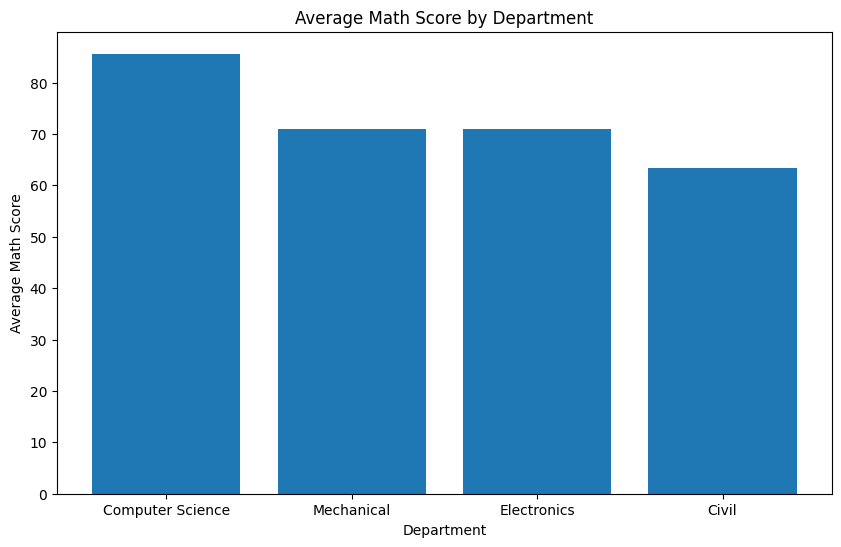

In [88]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

chart_sql = """
SELECT department, ROUND(AVG(math_score),2) AS avg_math_score
FROM students
WHERE department IS NOT NULL
GROUP BY department
ORDER BY avg_math_score DESC
"""
chart_data = pd.read_sql_query(chart_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart_data['department'], chart_data['avg_math_score'])
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score by Department')

plt.show()

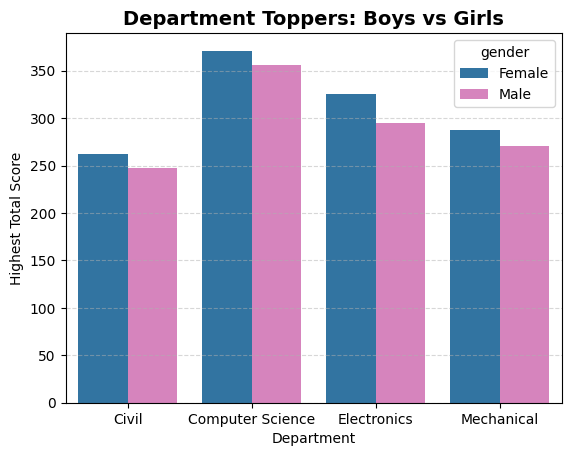

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('student_performance.csv')


df['total_score'] = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']


df_toppers = df.groupby(['department', 'gender'])['total_score'].max().reset_index()


sns.barplot(data=df_toppers, x='department', y='total_score', hue='gender', palette=['#1f77b4', '#e377c2'])


plt.title('Department Toppers: Boys vs Girls', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Highest Total Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()